# Übung 2 - Histogrammanpassung #

## Aufgaben ##
1. Lesen Sie die Kapitel 5 (Punktoperationen- 5.2 Punktoperationen und Histogramme) und Kapitel 6 (Filter 6.1- 6.3) aus dem Buch ”Digitale Bildverarbeitung”. <br>
2. Implementieren Sie eine Funktion, die aus einem 8-Bit-Graustufenbild das zugehörige kumulative Histogramm berechnet. <br>
• Prototyp: cumHisto = compute cumHisto(image, binSize) <br>
• Das image ist ein 8-Bit-Grauwert Bild. <br>
3. Beantworten Sie folgende Fragen: <br>
a) Was ist eine homogene und was eine nicht-homogene Punktoperation? <br>
b) Was ist der Unterschied zwischen Punktoperationen und Filteroperationen? <br>
4. Implementieren Sie eine Funktion, die das Bild01 an das Bild02 mittels Histogrammanpassung angleicht. <br>
Hierzu soll das kumulative Histogramm von Bild02 als Referenzverteilung dienen und das Bild01 so verändert werden, <br>
dass sein kumulatives Histogramm an die Referenzverteilung angeglichen wird. <br>
Schließlich soll das Referenzbild (02) und das verarbeitete Bild (01) und deren kumulativen Histogramme angezeigt werden. <br>
• Prototyp: LUT = match Histo(img histo, ref histo) <br>
• img histo: Histogramm des anzupassenden Bildes. <br>
• ref histo: Histogramm des Referenzbildes. <br>
• LUT: Die Lookup Tabelle, welche auf das anzupassende Bild angewendet, die Histogrammanpassung durchführt. <br>
Wieso müssen die beiden Histogramme des Referenz- und des Orginalbildes normiert sein? (Denken Sie an den Histogrammausgleich) <br>

In [11]:
import matplotlib.pyplot as plt
from skimage import io
import numpy as np

In [2]:
# bilder einlesen
pfad = "C:/Users/Ann-Kathrin/Desktop/htwg/semester05/2DCV/uebung2/"
dateien = ["bild01.jpg", "bild02.jpg"]

bild01 = io.imread(pfad + dateien[0])
bild02 = io.imread(pfad + dateien[1])

In [3]:
# in graustufen bild umwandeln
def bunt_zu_grau(image):
    # falls bunt -> grau
    if len(image.shape) == 3:
        gray = (
            0.299 * image[:, :, 0] +
            0.587 * image[:, :, 1] +
            0.114 * image[:, :, 2]
        )
        return gray.astype(np.uint8)
    return image

bild01_gray = bunt_zu_grau(bild01)
bild02_gray = bunt_zu_grau(bild02)

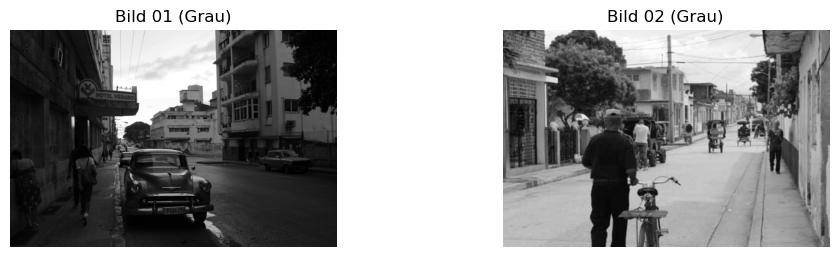

In [17]:
# grau bilder
plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.title("Bild 01 (Grau)")
plt.imshow(bild01_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Bild 02 (Grau)")
plt.imshow(bild02_gray, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Aufgabe 3 <br>
a) Unterschied homogene und nicht-homogene Punktoperation <br>
Homogene Punktoperation ist unabhänig von den Bildkoordinaten
Nicht-homogene Punktoperationen ist abhäning von der Position, Transformation ist nicht für alle Pixel gleich. <br>
b) Unterschied zwischen Punktoperationen und Filteroperationen?
Bei Punktoperationen werden die Pixel unabhäning voneinander berücksichtigt <br> bei Filteroperationen bezieht die Umgebung eines Pixels mit ein (zb Glättung)

In [5]:
# histogramm
def computeHisto(image):
    histo = np.zeros(256, dtype=int)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            histo[image[y, x]] += 1

    return histo

In [ ]:
# kumulatives histogramm (aufgabe2)
def compute_cumHisto(image, binSize=256):
    histo = computeHisto(image)

    # Normieren
    histo = histo / np.sum(histo)

    # Kumulieren
    cumHisto = np.cumsum(histo)

    return cumHisto

In [ ]:
# LookUpTable aufgabe4
def match_Histo(img_histo, ref_histo):
    # Normieren
    img_histo = img_histo / np.sum(img_histo) # jeden Histogrammwert durch die Gesamtanzahl der Pixel teilen ->Wahrscheinlichkeitsverteilung (anteile)
    ref_histo = ref_histo / np.sum(ref_histo)

    # kumulatives histogramm (cdf) ->Verteilfunktion
    img_cum = np.cumsum(img_histo)
    ref_cum = np.cumsum(ref_histo)

    LUT = np.zeros(256, dtype=np.uint8)

    j = 0
    for i in range(256): #Für jeden Grauwert i im Bild, suche den Wert j im Referenzbild
        while j < 255 and ref_cum[j] < img_cum[i]:
            j += 1
        LUT[i] = j

    return LUT

In [8]:
def apply_LUT(image, LUT):
    result = np.zeros_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            result[y, x] = LUT[image[y, x]]

    return result

In [9]:
histo1 = computeHisto(bild01_gray)
histo2 = computeHisto(bild02_gray)

cum1 = compute_cumHisto(bild01_gray)
cum2 = compute_cumHisto(bild02_gray)

LUT = match_Histo(histo1, histo2)

bild01_matched = apply_LUT(bild01_gray, LUT)

cum_matched = compute_cumHisto(bild01_matched)

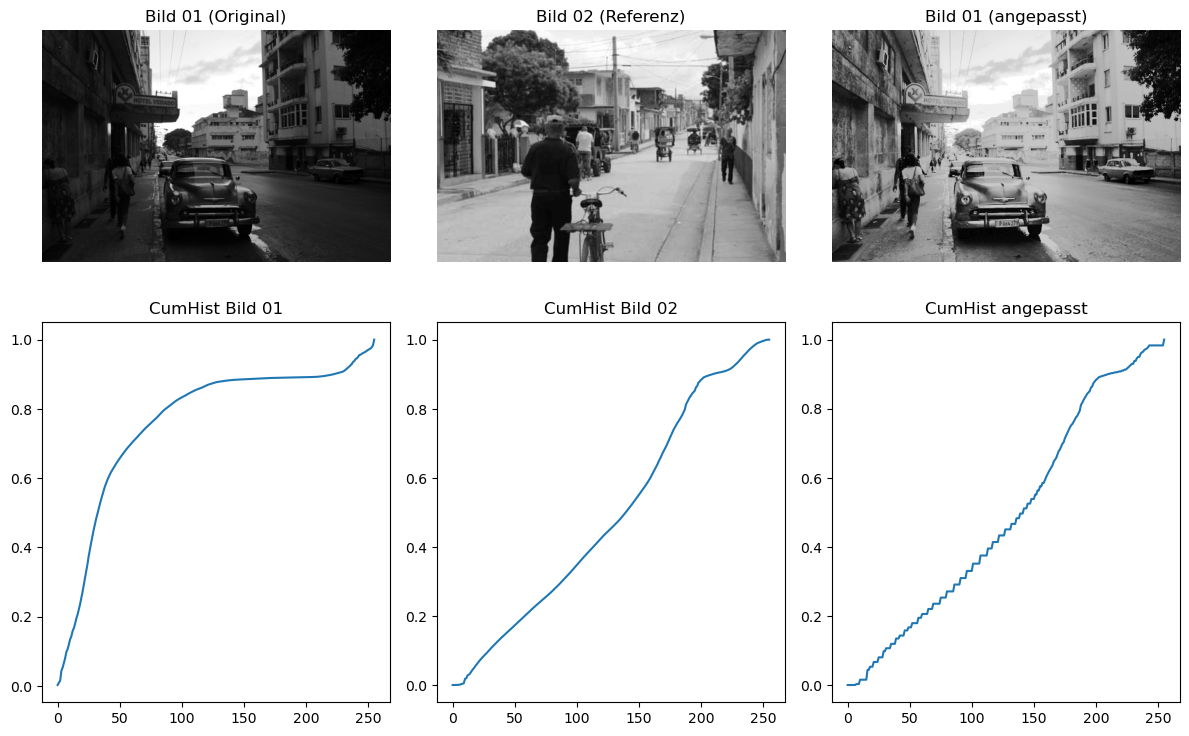

In [10]:
plt.figure(figsize=(12, 8))

# bilder
plt.subplot(2, 3, 1)
plt.title("Bild 01 (Original)")
plt.imshow(bild01_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Bild 02 (Referenz)")
plt.imshow(bild02_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Bild 01 (angepasst)")
plt.imshow(bild01_matched, cmap='gray')
plt.axis('off')

# kumulatives histogramme
plt.subplot(2, 3, 4)
plt.title("CumHist Bild 01")
plt.plot(cum1)

plt.subplot(2, 3, 5)
plt.title("CumHist Bild 02")
plt.plot(cum2)

plt.subplot(2, 3, 6)
plt.title("CumHist angepasst")
plt.plot(cum_matched)

plt.tight_layout()
plt.show()